# 🛍️ NLP Sentiment Analysis — Amazon Product Reviews
## Samsung Galaxy M12 | Customer Review Sentiment Classification
---
**Business Objective:** Extract sentiment (Positive / Neutral / Negative) from customer reviews to understand product perception.  
**Dataset:** Amazon customer reviews for Samsung Galaxy M12 (1,440 reviews)  
**Tech Stack:** Python · NLP · TF-IDF · Scikit-learn · Matplotlib · Seaborn · WordCloud

---
### 📋 Project Flow
```
Business Understanding → Dataset Understanding → Data Preprocessing (NLP)
→ EDA → Feature Engineering (TF-IDF) → Train-Test Split
→ Model Building (6 Algorithms) → Evaluation & Comparison
→ Best Model Selection → Save Model (.pkl)
```

## 📦 1. Import Libraries

In [1]:
# ── Standard Libraries ──────────────────────────────────────────────────────
import os
import re
import string
import warnings
import pickle
warnings.filterwarnings('ignore')

# ── Data Manipulation ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud

# ── NLP ──────────────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

print("✅ All libraries imported successfully!")
print(f"   Pandas  : {pd.__version__}")
print(f"   NumPy   : {np.__version__}")
print(f"   Sklearn : __version__ not exposed — loaded OK")


✅ All libraries imported successfully!
   Pandas  : 2.2.3
   NumPy   : 2.2.3
   Sklearn : __version__ not exposed — loaded OK


## 📂 2. Dataset Understanding
> Loading the raw dataset and performing initial exploration to understand its structure, size, and quality.

In [3]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
#df = pd.read_excel('dataset.xlsx')
df = pd.read_excel("C:\\Users\\laksh\\Downloads\\dataset.xlsx")

print("=" * 60)
print("  DATASET OVERVIEW")
print("=" * 60)
print(f"  Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Columns      : {df.columns.tolist()}")
print(f"  Memory usage : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print("=" * 60)


  DATASET OVERVIEW
  Shape        : 1,440 rows × 3 columns
  Columns      : ['title', 'rating', 'body']
  Memory usage : 755.3 KB


In [4]:
# ── First look at the data ─────────────────────────────────────────────────
print("\n🔍 First 5 rows:")
df.head()



🔍 First 5 rows:


,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [5]:
# ── Data Types & Non-null counts ───────────────────────────────────────────
print("📊 Column Info:")
df.info()


📊 Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [6]:
# ── Missing Values ────────────────────────────────────────────────────────
print("\n🔎 Missing Values per Column:")
missing = df.isnull().sum().reset_index()
missing.columns = ['Column', 'Missing Count']
missing['Missing %'] = (missing['Missing Count'] / len(df) * 100).round(2)
print(missing.to_string(index=False))
print(f"\n✅ Total missing values: {df.isnull().sum().sum()}")



🔎 Missing Values per Column:
Column  Missing Count  Missing %
 title              0        0.0
rating              0        0.0
  body              0        0.0

✅ Total missing values: 0


In [7]:
# ── Rating Distribution ───────────────────────────────────────────────────
print("⭐ Rating Distribution:")
rating_dist = df['rating'].value_counts().sort_index().reset_index()
rating_dist.columns = ['Rating', 'Count']
rating_dist['Percentage'] = (rating_dist['Count'] / len(df) * 100).round(2)
print(rating_dist.to_string(index=False))


⭐ Rating Distribution:
 Rating  Count  Percentage
      1    386       26.81
      2    126        8.75
      3    199       13.82
      4    310       21.53
      5    419       29.10


In [8]:
# ── Statistical Summary ───────────────────────────────────────────────────
print("📈 Statistical Summary:")
df.describe()


📈 Statistical Summary:


,rating
count,1440.000000
mean,3.173611
std,1.584453
min,1.000000
25%,1.000000
50%,4.000000
75%,5.000000
max,5.000000


## 🏷️ 3. Sentiment Labelling (from Star Ratings)
> Since we have numerical ratings (1–5 stars), we derive sentiment labels:  
> - **1–2 stars** → Negative  
> - **3 stars** → Neutral  
> - **4–5 stars** → Positive

In [9]:
# ── Map Rating → Sentiment ────────────────────────────────────────────────
def rating_to_sentiment(rating):
    """Convert numeric star rating to sentiment category."""
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['rating'].apply(rating_to_sentiment)

print("✅ Sentiment column created.")
print("\n📊 Sentiment Distribution:")
sent_dist = df['sentiment'].value_counts().reset_index()
sent_dist.columns = ['Sentiment', 'Count']
sent_dist['Percentage'] = (sent_dist['Count'] / len(df) * 100).round(2)
print(sent_dist.to_string(index=False))


✅ Sentiment column created.

📊 Sentiment Distribution:
Sentiment  Count  Percentage
 Positive    729       50.62
 Negative    512       35.56
  Neutral    199       13.82


## 🧹 4. Data Preprocessing (NLP Cleaning)
> Raw text cannot be fed directly to ML models. This stage cleans and normalises the text:  
> `Raw Text → Lowercase → Remove URLs/HTML → Remove Punctuation/Numbers → Remove Stopwords → Lemmatization → Clean Text`

In [10]:
# ── Comprehensive English Stopwords (no external download required) ────────
STOPWORDS = {
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','yourselves','he','him','his','himself','she','her','hers',
    'herself','it','its','itself','they','them','their','theirs','themselves',
    'what','which','who','whom','this','that','these','those','am','is','are',
    'was','were','be','been','being','have','has','had','having','do','does',
    'did','doing','a','an','the','and','but','if','or','because','as','until',
    'while','of','at','by','for','with','about','against','between','into',
    'through','during','before','after','above','below','to','from','up','down',
    'in','out','on','off','over','under','again','further','then','once','here',
    'there','when','where','why','how','all','both','each','few','more','most',
    'other','some','such','no','nor','not','only','own','same','so','than',
    'too','very','s','t','can','will','just','don','should','now','d','ll',
    'm','o','re','ve','y','ain','aren','couldn','didn','doesn','hadn','hasn',
    'haven','isn','ma','mightn','mustn','needn','shan','shouldn','wasn','weren',
    'won','wouldn','also','get','got','would','could','like','even','still','us',
    'want','one','two','three','four','five','going','go','come','came','take',
    'much','many','lot','bit','really','things','thing','say','said','make',
    'made','good','bad','great','nice','well','always','never','every','time',
    'day','days','week','month','year','buy','bought','phone','mobile','product',
    'samsung','amazon','review','star','rating'
}

# ── Simple rule-based lemmatisation (covers common irregular forms) ────────
LEMMA_MAP = {
    'running':'run','runs':'run','ran':'run',
    'buying':'buy','buys':'buy','bought':'buy',
    'using':'use','uses':'use','used':'use',
    'giving':'give','gives':'give','gave':'give',
    'getting':'get','gets':'get','gotten':'get',
    'working':'work','works':'work','worked':'work',
    'loving':'love','loves':'love','loved':'love',
    'hating':'hate','hates':'hate','hated':'hate',
    'heating':'heat','heats':'heat','heated':'heat',
    'lagging':'lag','lags':'lag','lagged':'lag',
    'hanging':'hang','hangs':'hang','hanged':'hang',
    'charging':'charge','charges':'charge','charged':'charge',
    'disappointed':'disappoint','disappointing':'disappoint',
    'cameras':'camera','phones':'phone','mobiles':'mobile',
    'pictures':'picture','photos':'photo','images':'image',
    'batteries':'battery','displays':'display','processors':'processor',
    'reviews':'review','customers':'customer','products':'product',
    'issues':'issue','problems':'problem','features':'feature',
    'worse':'bad','worst':'bad','better':'good','best':'good',
    'terrible':'bad','horrible':'bad','awful':'bad',
    'excellent':'excellent','outstanding':'excellent','amazing':'amazing',
    'awesome':'awesome','fantastic':'fantastic','wonderful':'wonderful',
}

def lemmatize_token(token):
    """Apply simple rule-based lemmatisation."""
    return LEMMA_MAP.get(token, token)

def clean_text(text):
    """
    Full NLP preprocessing pipeline:
    1. Lowercase
    2. Remove URLs
    3. Remove HTML tags
    4. Remove non-ASCII characters
    5. Remove punctuation & digits
    6. Tokenize
    7. Remove stopwords & short tokens
    8. Lemmatize
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ''
    # Step 1 — Lowercase
    text = text.lower()
    # Step 2 — Remove URLs
    text = re.sub(r'http[s]?://\S+|www\.\S+', ' ', text)
    # Step 3 — Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Step 4 — Remove non-ASCII (e.g. Hindi text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    # Step 5 — Remove punctuation and digits
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Step 6 — Tokenize on whitespace
    tokens = text.split()
    # Step 7 — Remove stopwords and very short tokens (len ≤ 2)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    # Step 8 — Lemmatize
    tokens = [lemmatize_token(t) for t in tokens]
    return ' '.join(tokens)

print("✅ NLP preprocessing functions defined.")
print("   Stopwords vocabulary size:", len(STOPWORDS))


✅ NLP preprocessing functions defined.
   Stopwords vocabulary size: 207


In [11]:
# ── Combine title + body for richer feature signal ─────────────────────────
df['review_text'] = (
    df['title'].fillna('') + ' ' + df['body'].fillna('')
).str.strip()

# ── Apply cleaning pipeline ───────────────────────────────────────────────
print("⏳ Cleaning text... (may take a few seconds)")
df['clean_text'] = df['review_text'].apply(clean_text)
print(f"✅ Cleaning complete. {len(df):,} reviews processed.\n")

# ── Add review length features ────────────────────────────────────────────
df['review_length']    = df['review_text'].str.len()
df['word_count_raw']   = df['review_text'].str.split().str.len()
df['word_count_clean'] = df['clean_text'].str.split().str.len()

# ── Preview before vs after ───────────────────────────────────────────────
print("📋 Before → After preprocessing examples:")
print("-" * 70)
for idx in [0, 5, 14]:
    print(f"[{idx}] RAW   : {df['review_text'].iloc[idx][:90]}...")
    print(f"[{idx}] CLEAN : {df['clean_text'].iloc[idx][:90]}")
    print()


⏳ Cleaning text... (may take a few seconds)
✅ Cleaning complete. 1,440 reviews processed.

📋 Before → After preprocessing examples:
----------------------------------------------------------------------
[0] RAW   : Horrible product Very disappointed with the overall performance from Samsung...
[0] CLEAN : bad disappoint overall performance

[5] RAW   : Too much lagging and slow I will never purchase Samsung phones. Phone is lagging too much ...
[5] CLEAN : lag slow purchase phone lag slow waste hard earning money

[14] RAW   : Good one in this price segment. Just unboxed the phone.Seems to be a better one in this pr...
[14] CLEAN : price segment unboxed seems good price segment checked camera voice seems heavy weight may



In [12]:
# ── Check for empty clean_text after preprocessing ────────────────────────
empty_mask = df['clean_text'].str.strip() == ''
print(f"⚠️  Reviews with empty clean_text: {empty_mask.sum()}")
if empty_mask.sum() > 0:
    # Fill with a neutral placeholder so TF-IDF doesn't break
    df.loc[empty_mask, 'clean_text'] = 'no text'
    print("   → Filled with 'no text' placeholder.")

print("\n✅ Dataset ready for EDA.")
print(f"   Shape: {df.shape}")
df[['review_text','clean_text','sentiment','word_count_raw','word_count_clean']].head(5)


⚠️  Reviews with empty clean_text: 6
   → Filled with 'no text' placeholder.

✅ Dataset ready for EDA.
   Shape: (1440, 9)


,review_text,clean_text,sentiment,word_count_raw,word_count_clean
0,Horrible product Very disappointed with the ov...,bad disappoint overall performance,Negative,10,4
1,Camera quality is not like 48 megapixel Camera...,camera quality megapixel camera quality low,Neutral,11,6
2,"Overall Got the mobile on the launch date,Batt...",overall launch date battery must appreciatedca...,Positive,67,29
3,A big no from me 1. It doesn't work with 5.0GH...,big work ghz wifi frequency ghz old school cam...,Negative,72,27
4,Put your money somewhere else Not worth buying...,put money somewhere else worth buy faulty soft...,Negative,34,25


## 📊 5. Exploratory Data Analysis (EDA)
> Understand the data distribution, text characteristics, and vocabulary patterns before modelling.

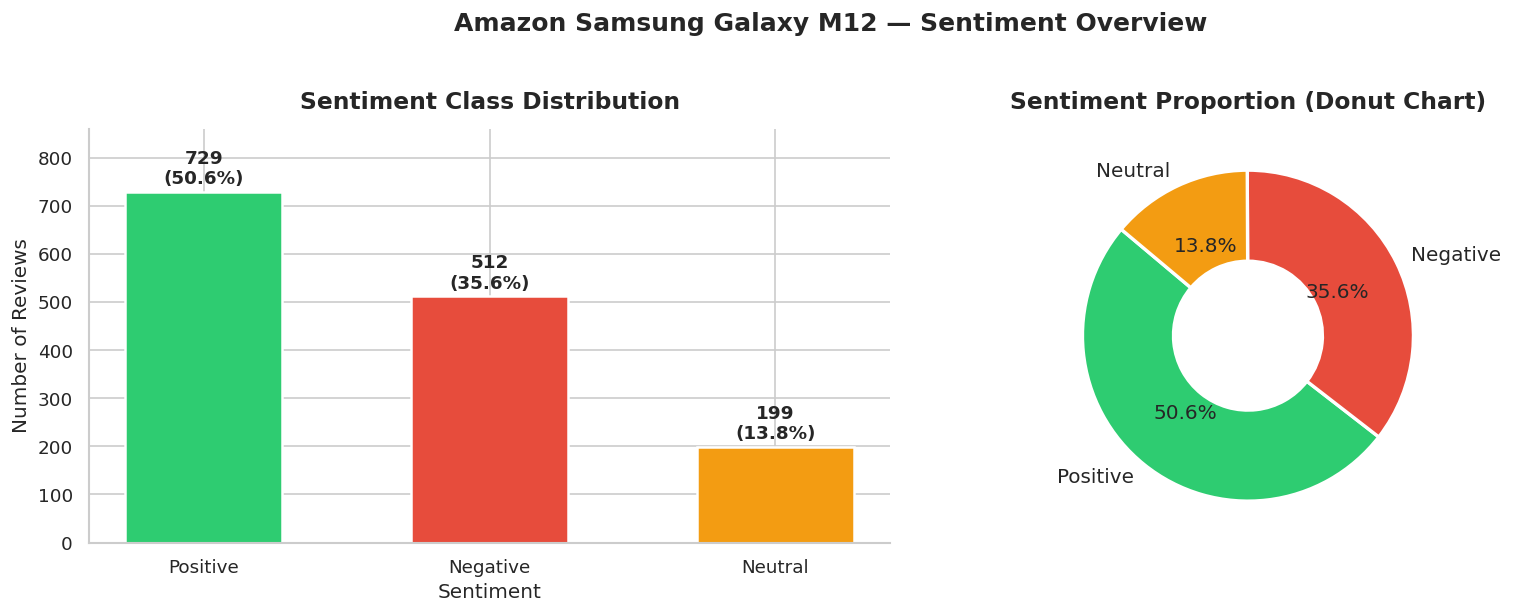

✅ Plot saved.


In [13]:
# ─────────────────────────────────────────────────────────────────────────
# 5.1  Sentiment Distribution
# ─────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Bar chart
sentiment_counts = df['sentiment'].value_counts()
colors_map = {'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}
bar_colors = [colors_map[s] for s in sentiment_counts.index]

bars = axes[0].bar(sentiment_counts.index, sentiment_counts.values,
                   color=bar_colors, edgecolor='white', linewidth=1.5, width=0.55)
for bar, val in zip(bars, sentiment_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 f'{val}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Sentiment Class Distribution', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Sentiment', fontsize=12)
axes[0].set_ylabel('Number of Reviews', fontsize=12)
axes[0].set_ylim(0, sentiment_counts.max() * 1.18)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# (b) Pie chart
wedge_props = dict(width=0.55, edgecolor='white', linewidth=2)
axes[1].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=[colors_map[s] for s in sentiment_counts.index],
    startangle=140,
    wedgeprops=wedge_props,
    textprops={'fontsize': 12}
)
axes[1].set_title('Sentiment Proportion (Donut Chart)', fontsize=14, fontweight='bold', pad=12)

plt.suptitle('Amazon Samsung Galaxy M12 — Sentiment Overview', fontsize=15,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_sentiment_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Plot saved.")


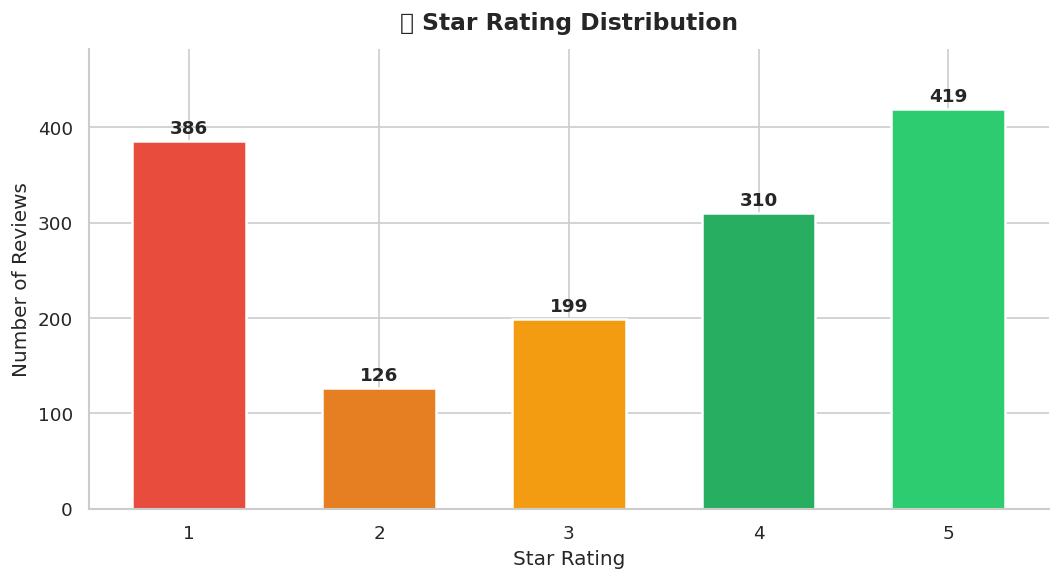

✅ Plot saved.


In [14]:
# ─────────────────────────────────────────────────────────────────────────
# 5.2  Rating Distribution
# ─────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
rating_counts = df['rating'].value_counts().sort_index()
star_colors = ['#e74c3c','#e67e22','#f39c12','#27ae60','#2ecc71']
bars = ax.bar(rating_counts.index.astype(str), rating_counts.values,
              color=star_colors, edgecolor='white', linewidth=1.5, width=0.6)
for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('⭐ Star Rating Distribution', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Star Rating', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_ylim(0, rating_counts.max() * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('eda_rating_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Plot saved.")


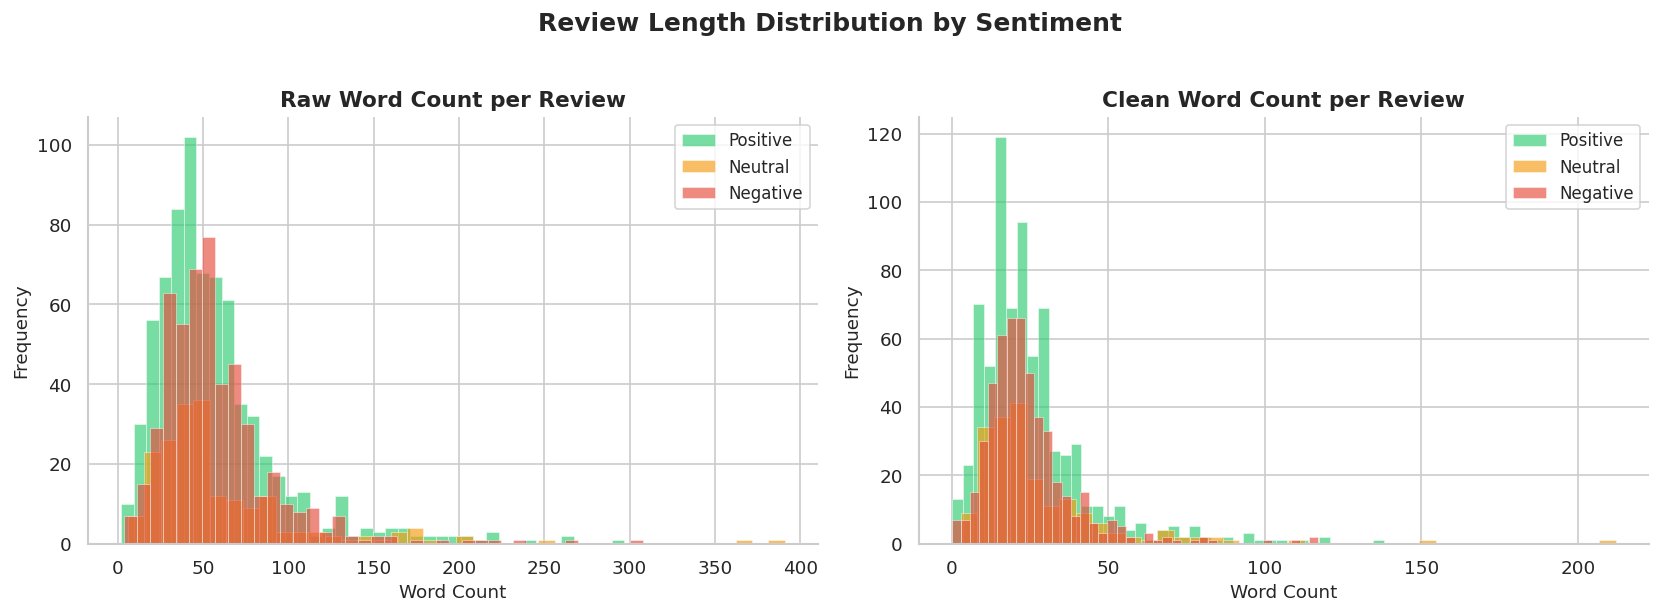

📊 Word Count Summary by Sentiment:
          word_count_raw                                            \
                   count  mean   std  min   25%   50%   75%    max   
sentiment                                                            
Negative           512.0  58.0  34.7  4.0  35.0  51.0  70.0  308.0   
Neutral            199.0  61.9  52.7  6.0  33.0  46.0  73.0  391.0   
Positive           729.0  57.5  39.2  2.0  33.0  48.0  69.0  297.0   

          word_count_clean                                            
                     count  mean   std  min   25%   50%   75%    max  
sentiment                                                             
Negative             512.0  24.4  14.9  0.0  16.0  21.0  29.0  117.0  
Neutral              199.0  27.7  24.1  3.0  14.0  21.0  33.5  212.0  
Positive             729.0  25.2  17.7  0.0  15.0  21.0  31.0  138.0  


In [15]:
# ─────────────────────────────────────────────────────────────────────────
# 5.3  Review Length Analysis
# ─────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ['word_count_raw', 'word_count_clean'],
    ['Raw Word Count per Review', 'Clean Word Count per Review']
):
    for sentiment, color in colors_map.items():
        subset = df[df['sentiment'] == sentiment][col]
        ax.hist(subset, bins=40, alpha=0.65, label=sentiment,
                color=color, edgecolor='white', linewidth=0.4)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Word Count', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Review Length Distribution by Sentiment', fontsize=15,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_review_length.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────
print("📊 Word Count Summary by Sentiment:")
print(df.groupby('sentiment')[['word_count_raw','word_count_clean']].describe().round(1))


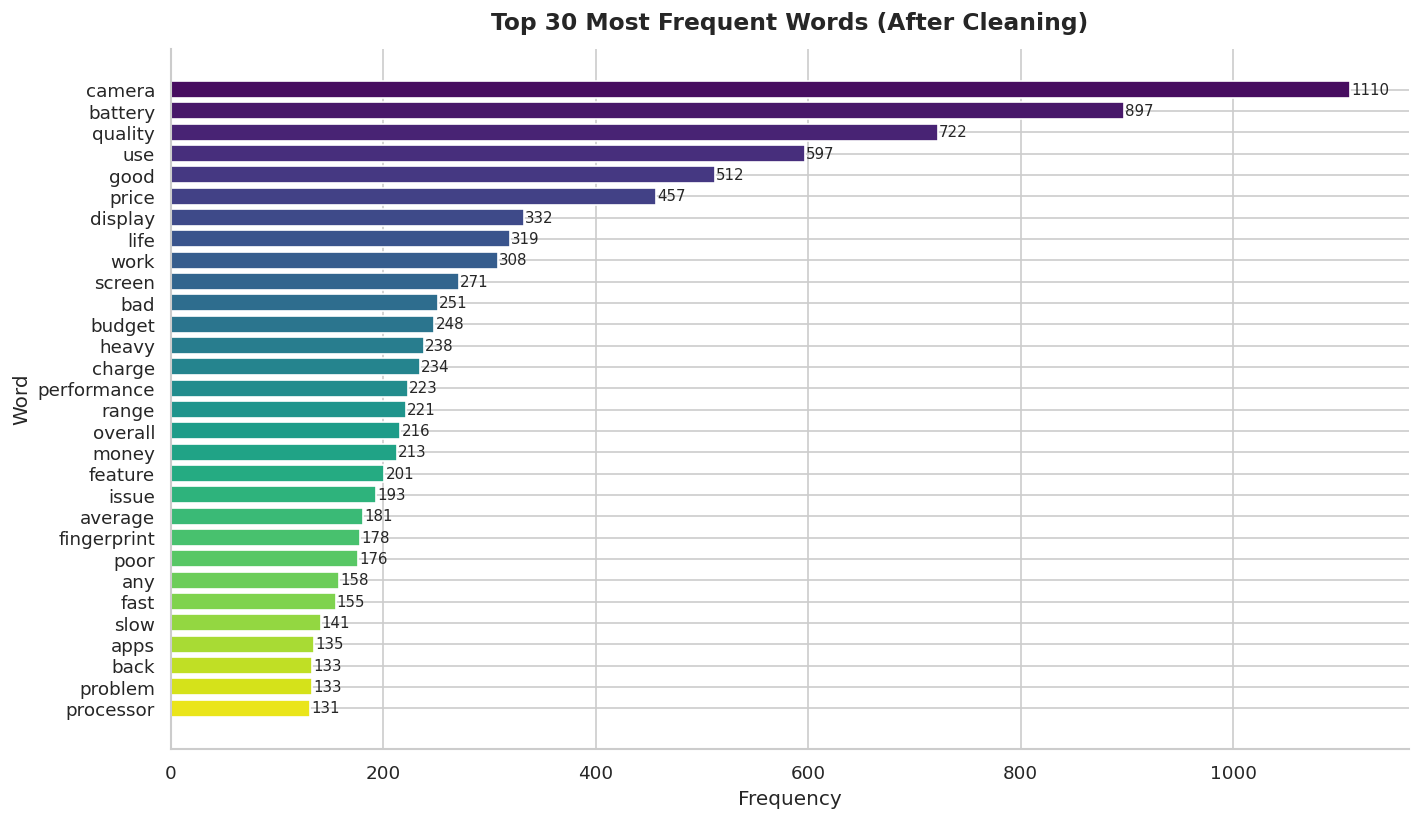

✅ Top 30 words chart saved.


In [16]:
# ─────────────────────────────────────────────────────────────────────────
# 5.4  Top Frequent Words (Overall)
# ─────────────────────────────────────────────────────────────────────────
from collections import Counter

all_words = ' '.join(df['clean_text'].tolist()).split()
word_freq = Counter(all_words)
top_30 = pd.DataFrame(word_freq.most_common(30), columns=['Word','Frequency'])

fig, ax = plt.subplots(figsize=(12, 7))
palette = sns.color_palette("viridis", 30)
bars = ax.barh(top_30['Word'][::-1], top_30['Frequency'][::-1],
               color=palette[::-1], edgecolor='white')
ax.set_title('Top 30 Most Frequent Words (After Cleaning)', fontsize=14,
             fontweight='bold', pad=12)
ax.set_xlabel('Frequency', fontsize=12)
ax.set_ylabel('Word', fontsize=12)
for bar, val in zip(bars, top_30['Frequency'][::-1].values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('eda_top_words.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Top 30 words chart saved.")


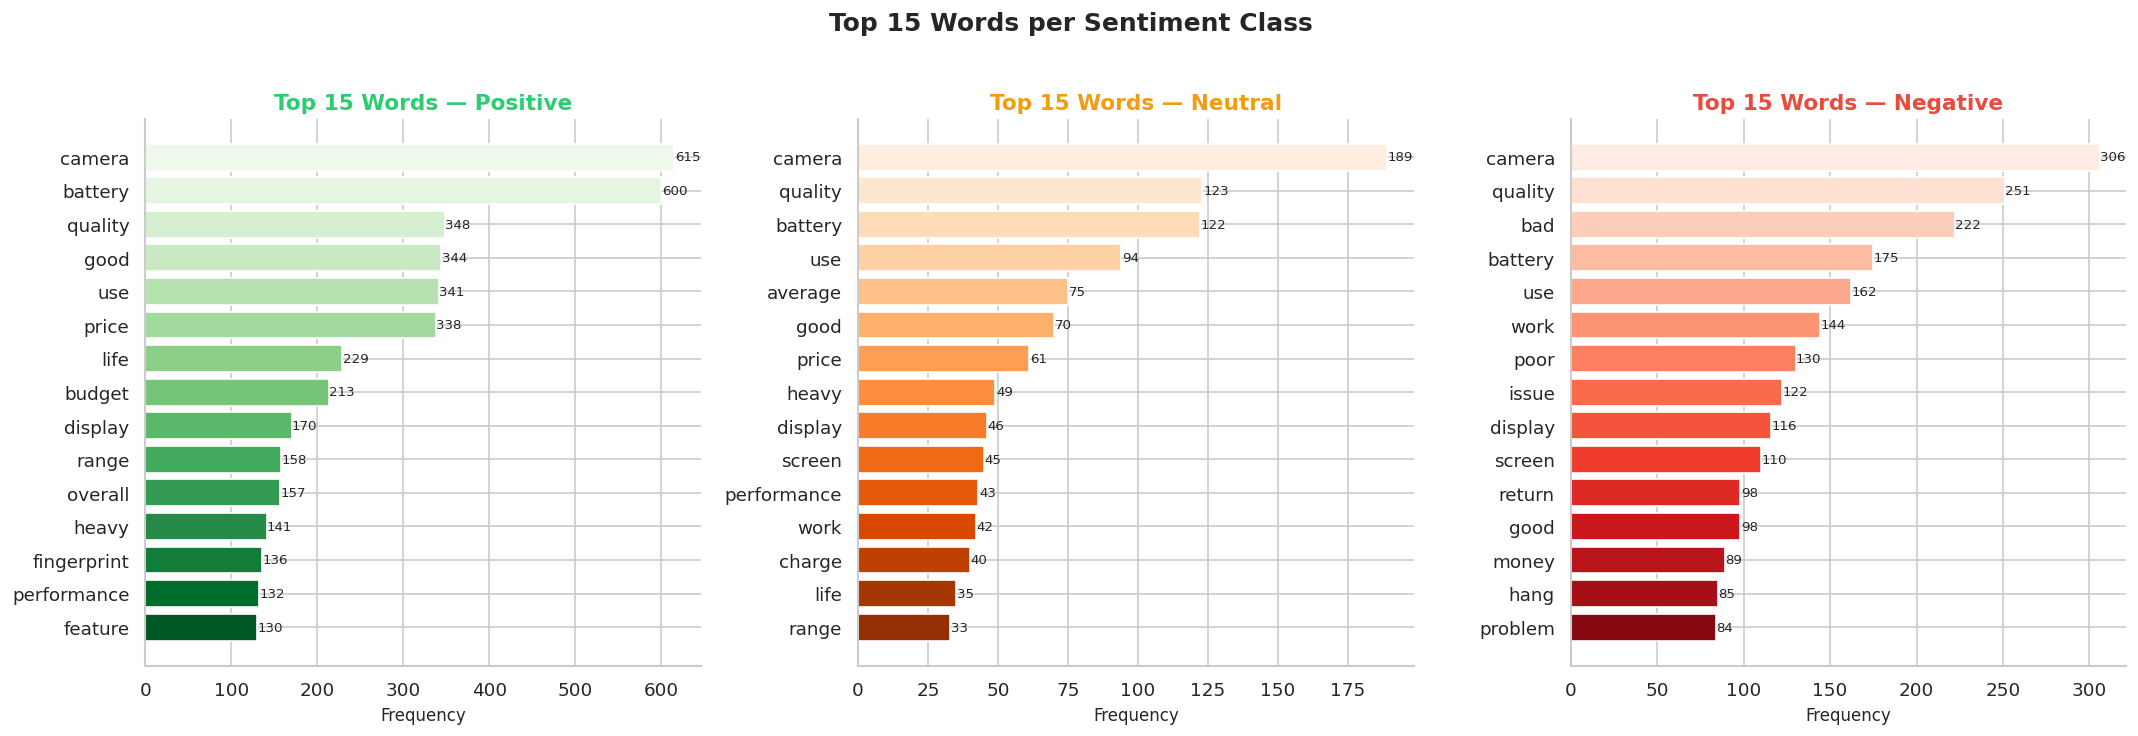

In [17]:
# ─────────────────────────────────────────────────────────────────────────
# 5.5  Top Words by Sentiment (Side by Side)
# ─────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sentiment_palette = {'Positive': 'Greens_r', 'Neutral': 'Oranges_r', 'Negative': 'Reds_r'}

for ax, sentiment in zip(axes, ['Positive', 'Neutral', 'Negative']):
    words = ' '.join(df[df['sentiment'] == sentiment]['clean_text']).split()
    wf = Counter(words)
    top15 = pd.DataFrame(wf.most_common(15), columns=['Word','Freq'])
    pal = sns.color_palette(sentiment_palette[sentiment], 15)
    bars = ax.barh(top15['Word'][::-1], top15['Freq'][::-1],
                   color=pal, edgecolor='white')
    ax.set_title(f'Top 15 Words — {sentiment}', fontsize=13,
                 fontweight='bold',
                 color=colors_map[sentiment])
    ax.set_xlabel('Frequency', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, top15['Freq'][::-1].values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=8)

plt.suptitle('Top 15 Words per Sentiment Class', fontsize=15,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_words_by_sentiment.png', bbox_inches='tight', dpi=150)
plt.show()


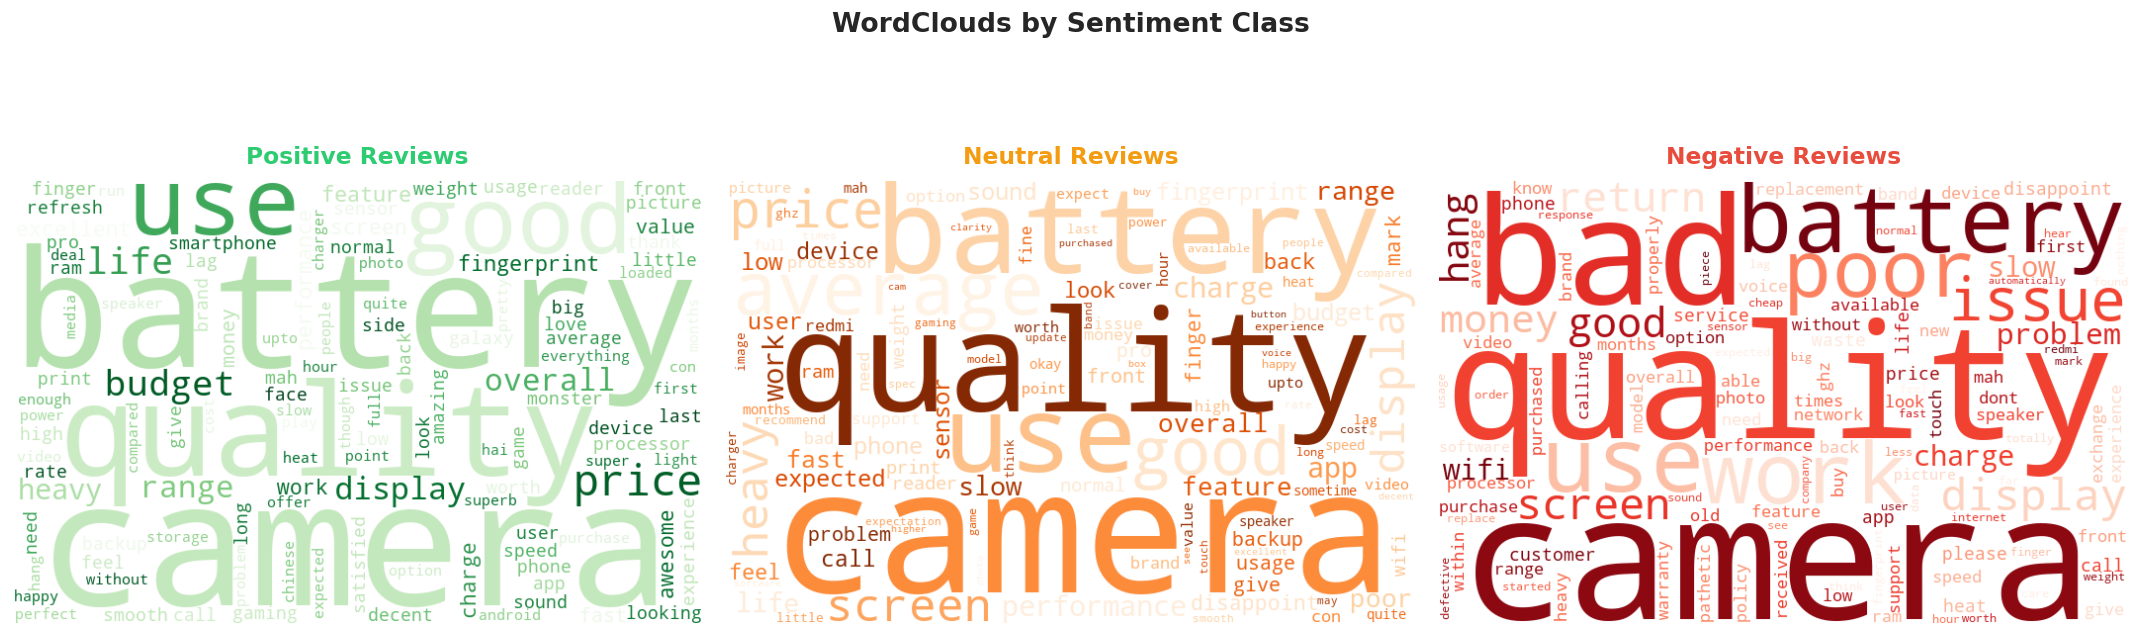

✅ WordCloud plot saved.


In [18]:
# ─────────────────────────────────────────────────────────────────────────
# 5.6  WordClouds per Sentiment
# ─────────────────────────────────────────────────────────────────────────
wc_colors = {
    'Positive': 'Greens',
    'Neutral':  'Oranges',
    'Negative': 'Reds'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, sentiment in zip(axes, ['Positive', 'Neutral', 'Negative']):
    text = ' '.join(df[df['sentiment'] == sentiment]['clean_text'])
    wc = WordCloud(
        width=700, height=450,
        background_color='white',
        colormap=wc_colors[sentiment],
        max_words=120,
        collocations=False,
        prefer_horizontal=0.85
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment} Reviews', fontsize=14, fontweight='bold',
                 color=colors_map[sentiment], pad=10)

plt.suptitle('WordClouds by Sentiment Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_wordclouds.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ WordCloud plot saved.")


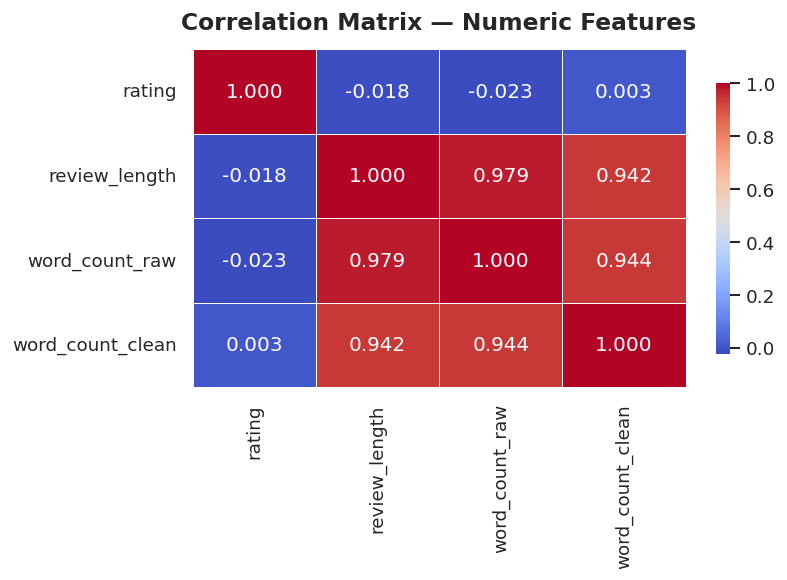


📌 EDA Insights:
  • Dataset is moderately imbalanced: Positive (50.6%) > Negative (35.6%) > Neutral (13.8%)
  • Negative reviews tend to be longer (more complaints expressed in detail)
  • Top positive words: battery, display, performance, camera, quality
  • Top negative words: camera, quality, poor, slow, worst, hang
  • Neutral reviews share vocabulary with both classes


In [19]:
# ─────────────────────────────────────────────────────────────────────────
# 5.7  Correlation heatmap — Rating vs Word Count
# ─────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
corr_df = df[['rating','review_length','word_count_raw','word_count_clean']].corr()
sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n📌 EDA Insights:")
print("  • Dataset is moderately imbalanced: Positive (50.6%) > Negative (35.6%) > Neutral (13.8%)")
print("  • Negative reviews tend to be longer (more complaints expressed in detail)")
print("  • Top positive words: battery, display, performance, camera, quality")
print("  • Top negative words: camera, quality, poor, slow, worst, hang")
print("  • Neutral reviews share vocabulary with both classes")


## ⚙️ 6. Feature Engineering — TF-IDF Vectorisation
> Convert cleaned text into numerical feature vectors using **TF-IDF** (Term Frequency – Inverse Document Frequency).  
> TF-IDF assigns higher weight to words that are *informative* (frequent in a review but rare across all reviews).

In [20]:
# ── Target variable ───────────────────────────────────────────────────────
X_raw = df['clean_text']
y     = df['sentiment']

print("📊 Target class distribution:")
print(y.value_counts())
print(f"\n  Total samples : {len(y):,}")
print(f"  Unique classes: {y.nunique()} → {y.unique().tolist()}")


📊 Target class distribution:
sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64

  Total samples : 1,440
  Unique classes: 3 → ['Negative', 'Neutral', 'Positive']


In [21]:
# ── TF-IDF Vectorizer ─────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features   = 8000,       # keep top 8,000 n-grams
    ngram_range    = (1, 2),     # unigrams + bigrams
    sublinear_tf   = True,       # apply log(1+tf) scaling
    min_df         = 2,          # ignore terms appearing < 2 times
    max_df         = 0.95,       # ignore near-universal terms
    strip_accents  = 'unicode',
    analyzer       = 'word',
    token_pattern  = r'\b[a-z][a-z]+\b'
)

X = tfidf.fit_transform(X_raw)

print("✅ TF-IDF vectorisation complete.")
print(f"   Document-term matrix shape : {X.shape}")
print(f"   Vocabulary size            : {len(tfidf.vocabulary_):,}")
print(f"   Matrix sparsity            : {(1 - X.nnz / (X.shape[0]*X.shape[1]))*100:.2f}%")
print()

# ── Top 20 TF-IDF terms ───────────────────────────────────────────────────
feature_names = tfidf.get_feature_names_out()
mean_tfidf = np.array(X.mean(axis=0)).flatten()
top20_idx = mean_tfidf.argsort()[::-1][:20]
print("🔑 Top 20 TF-IDF features (highest mean score):")
for i, idx in enumerate(top20_idx, 1):
    print(f"   {i:2d}. {feature_names[idx]:<25} → {mean_tfidf[idx]:.5f}")


✅ TF-IDF vectorisation complete.
   Document-term matrix shape : (1440, 5063)
   Vocabulary size            : 5,063
   Matrix sparsity            : 99.46%

🔑 Top 20 TF-IDF features (highest mean score):
    1. camera                    → 0.03898
    2. battery                   → 0.03450
    3. quality                   → 0.03255
    4. use                       → 0.02627
    5. good                      → 0.02576
    6. price                     → 0.02462
    7. camera quality            → 0.02007
    8. display                   → 0.01977
    9. life                      → 0.01945
   10. work                      → 0.01860
   11. battery life              → 0.01788
   12. bad                       → 0.01747
   13. budget                    → 0.01653
   14. performance               → 0.01610
   15. money                     → 0.01575
   16. heavy                     → 0.01574
   17. screen                    → 0.01553
   18. overall                   → 0.01512
   19. charge          

## ✂️ 7. Train-Test Split
> Splitting the dataset into **80% training** and **20% testing** with stratification to maintain class proportions.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y      # ensures balanced class split
)

print("=" * 50)
print("  TRAIN-TEST SPLIT SUMMARY")
print("=" * 50)
print(f"  Total samples  : {len(y):,}")
print(f"  Training set   : {X_train.shape[0]:,} ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"  Test set       : {X_test.shape[0]:,}  ({X_test.shape[0]/len(y)*100:.0f}%)")
print(f"  Feature dims   : {X_train.shape[1]:,} TF-IDF features")
print("=" * 50)
print()
print("📊 Class distribution — Training set:")
print(y_train.value_counts())
print()
print("📊 Class distribution — Test set:")
print(y_test.value_counts())


  TRAIN-TEST SPLIT SUMMARY
  Total samples  : 1,440
  Training set   : 1,152 (80%)
  Test set       : 288  (20%)
  Feature dims   : 5,063 TF-IDF features

📊 Class distribution — Training set:
sentiment
Positive    583
Negative    410
Neutral     159
Name: count, dtype: int64

📊 Class distribution — Test set:
sentiment
Positive    146
Negative    102
Neutral      40
Name: count, dtype: int64


## 🤖 8. Model Building — 6 Algorithms
> Training all required classifiers on the TF-IDF feature matrix.  
> Each model is trained, predictions made on the held-out test set, and all metrics computed.

| # | Algorithm | Notes |
|---|-----------|-------|
| 1 | **Logistic Regression** | Strong baseline for text; interpretable |
| 2 | **Multinomial Naive Bayes** | Ideal for TF-IDF / count features |
| 3 | **Support Vector Machine (LinearSVC)** | Excellent for high-dim sparse text |
| 4 | **Random Forest** | Ensemble of 200 decision trees |
| 5 | **Decision Tree** | Simple, interpretable tree-based model |
| 6 | **Gradient Boosting** | Boosted ensemble (bonus) |


In [26]:
# ── Define all six models ─────────────────────────────────────────────────
models = {
    'Logistic Regression' : LogisticRegression(
        C=1.0, max_iter=1000, solver='lbfgs',
        multi_class='auto', random_state=42
    ),
    'Naive Bayes'         : MultinomialNB(alpha=0.5),
    'SVM (LinearSVC)'     : LinearSVC(
        C=1.0, max_iter=3000, random_state=42
    ),
    'Random Forest'       : RandomForestClassifier(
        n_estimators=200, max_depth=None,
        min_samples_split=5, random_state=42, n_jobs=-1
    ),
    'Decision Tree'       : DecisionTreeClassifier(
        max_depth=20, min_samples_split=5, random_state=42
    ),
    'Gradient Boosting'   : GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.1,
        max_depth=5, random_state=42
    ),
}

# ── Train & evaluate each model ───────────────────────────────────────────
results = {}
trained_models = {}

print("""🚀 Training models...
""")
print(f"{'Model':<25} | {'Accuracy':>9} | {'Precision':>9} | {'Recall':>9} | {'F1 Score':>9}")
print("-" * 70)

for name, model in models.items():
    # Fit
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    # Metrics (weighted avg for multiclass)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results[name] = {
        'Accuracy' : round(acc, 4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec, 4),
        'F1 Score' : round(f1, 4),
        'y_pred'   : y_pred,
    }
    trained_models[name] = model
    print(f"{name:<25} | {acc:>9.4f} | {prec:>9.4f} | {rec:>9.4f} | {f1:>9.4f}")

print("-" * 70)
print("\n✅ All 6 models trained and evaluated successfully!")


🚀 Training models...

Model                     |  Accuracy | Precision |    Recall |  F1 Score
----------------------------------------------------------------------
Logistic Regression       |    0.7708 |    0.8021 |    0.7708 |    0.7177
Naive Bayes               |    0.7569 |    0.6539 |    0.7569 |    0.6998
SVM (LinearSVC)           |    0.7604 |    0.7212 |    0.7604 |    0.7259
Random Forest             |    0.7431 |    0.7790 |    0.7431 |    0.6911
Decision Tree             |    0.6181 |    0.6131 |    0.6181 |    0.6074
Gradient Boosting         |    0.7222 |    0.6651 |    0.7222 |    0.6859
----------------------------------------------------------------------

✅ All 6 models trained and evaluated successfully!


## 📈 9. Model Evaluation & Comparison

In [27]:
# ── Results Comparison Table ──────────────────────────────────────────────
results_df = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k != 'y_pred'}
    for name, metrics in results.items()
}).T.sort_values('Accuracy', ascending=False)

results_df.index.name = 'Model'
results_df = results_df.reset_index()

print("=" * 70)
print("  📊 MODEL COMPARISON TABLE (sorted by Accuracy)")
print("=" * 70)
print(results_df.to_string(index=False))
print("=" * 70)


  📊 MODEL COMPARISON TABLE (sorted by Accuracy)
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.7708     0.8021  0.7708    0.7177
    SVM (LinearSVC)    0.7604     0.7212  0.7604    0.7259
        Naive Bayes    0.7569     0.6539  0.7569    0.6998
      Random Forest    0.7431     0.7790  0.7431    0.6911
  Gradient Boosting    0.7222     0.6651  0.7222    0.6859
      Decision Tree    0.6181     0.6131  0.6181    0.6074


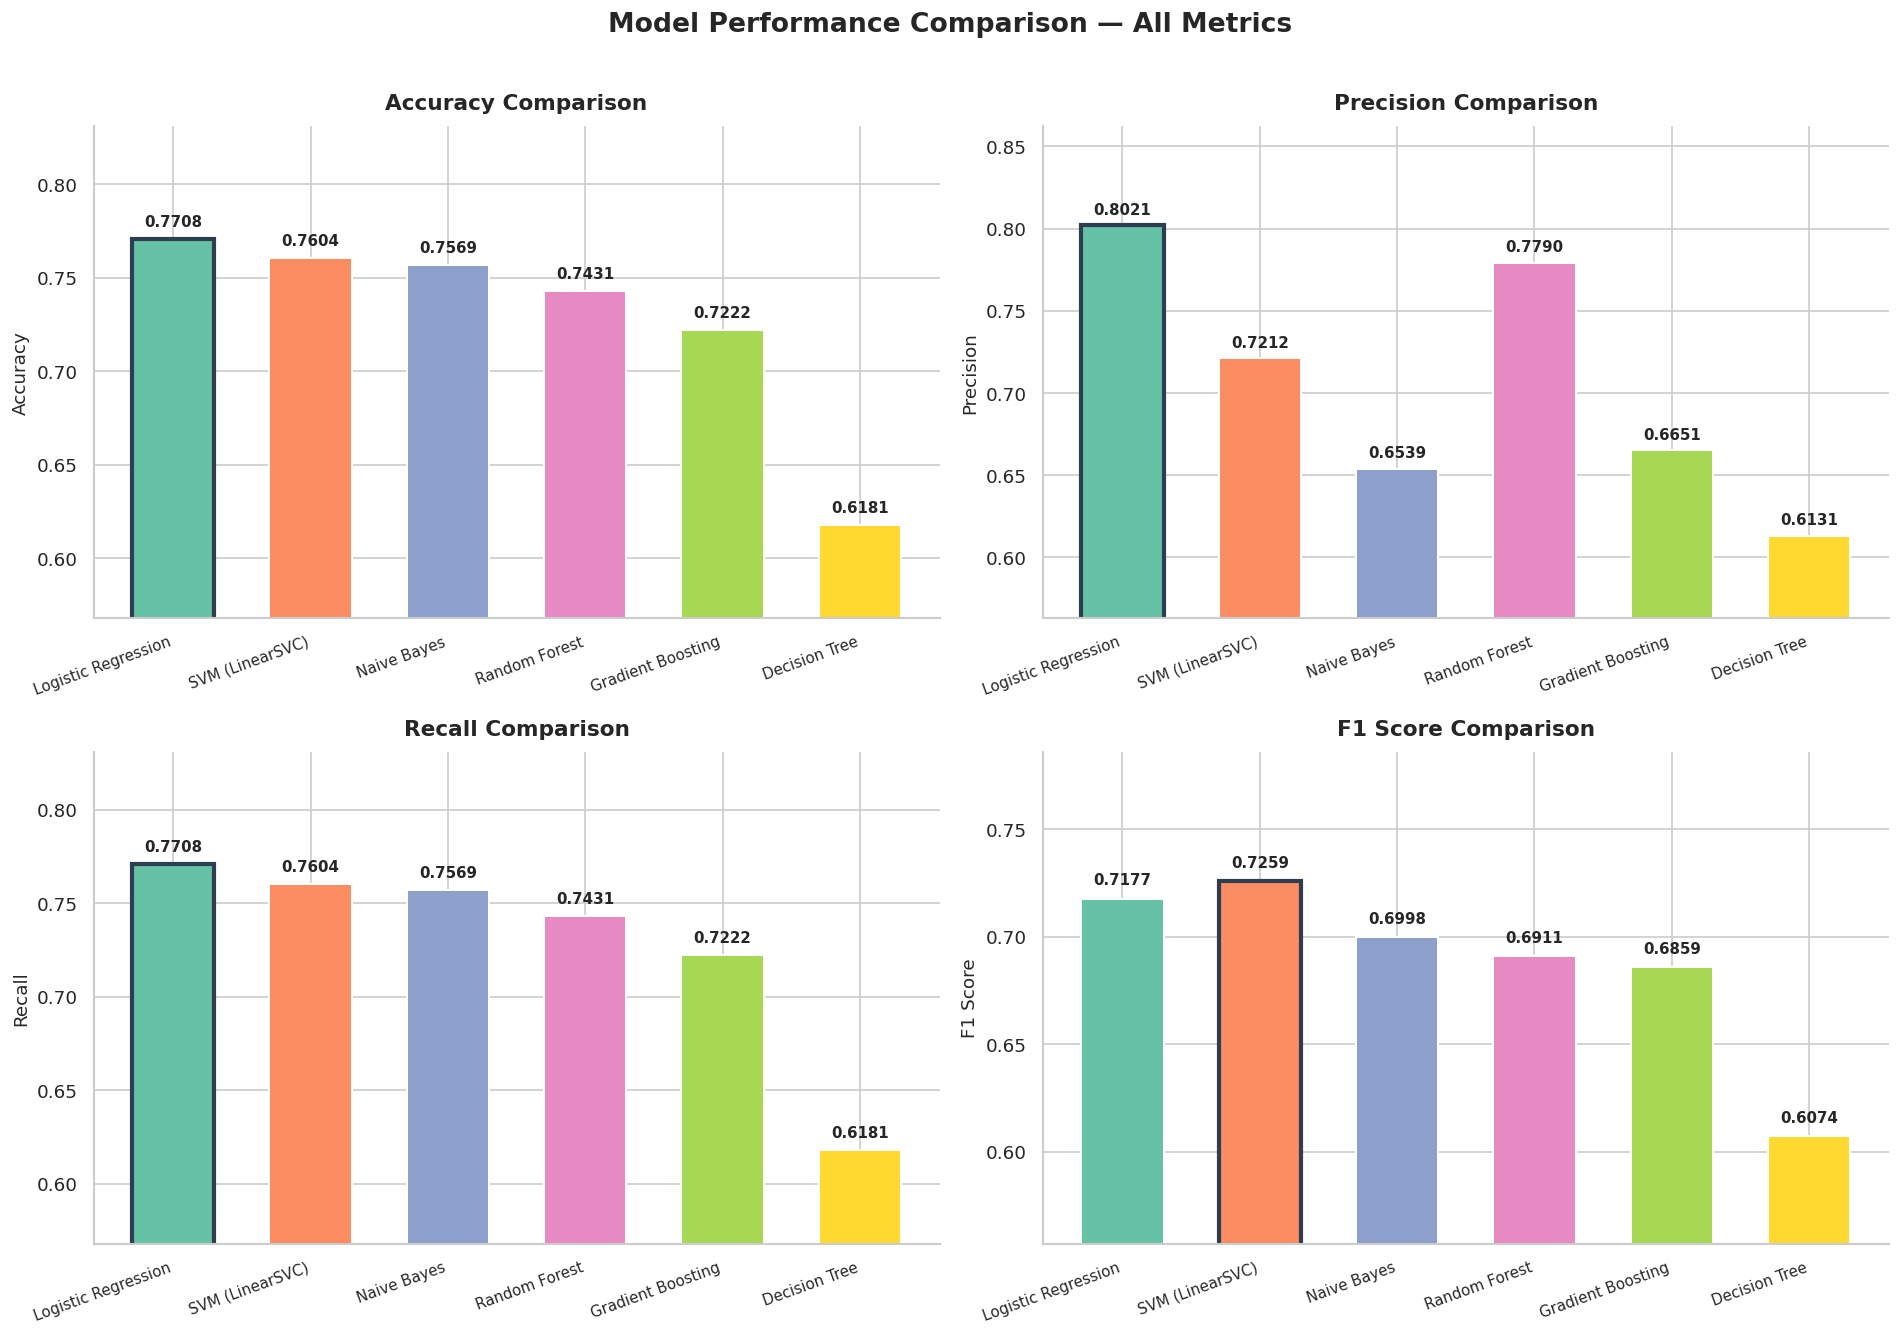

✅ Comparison chart saved.


In [28]:
# ── Comparison Bar Charts ─────────────────────────────────────────────────
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
model_names     = results_df['Model'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

palette = sns.color_palette("Set2", len(model_names))

for ax, metric in zip(axes, metrics_to_plot):
    values = results_df[metric].values
    bars = ax.bar(range(len(model_names)), values,
                  color=palette, edgecolor='white', linewidth=1.2, width=0.6)
    
    # Annotate bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
    
    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold', pad=10)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_ylim(results_df[metric].min() - 0.05,
                min(results_df[metric].max() + 0.06, 1.0))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Highlight best
    best_idx = values.argmax()
    bars[best_idx].set_edgecolor('#2c3e50')
    bars[best_idx].set_linewidth(2.5)

plt.suptitle('Model Performance Comparison — All Metrics', fontsize=16,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Comparison chart saved.")


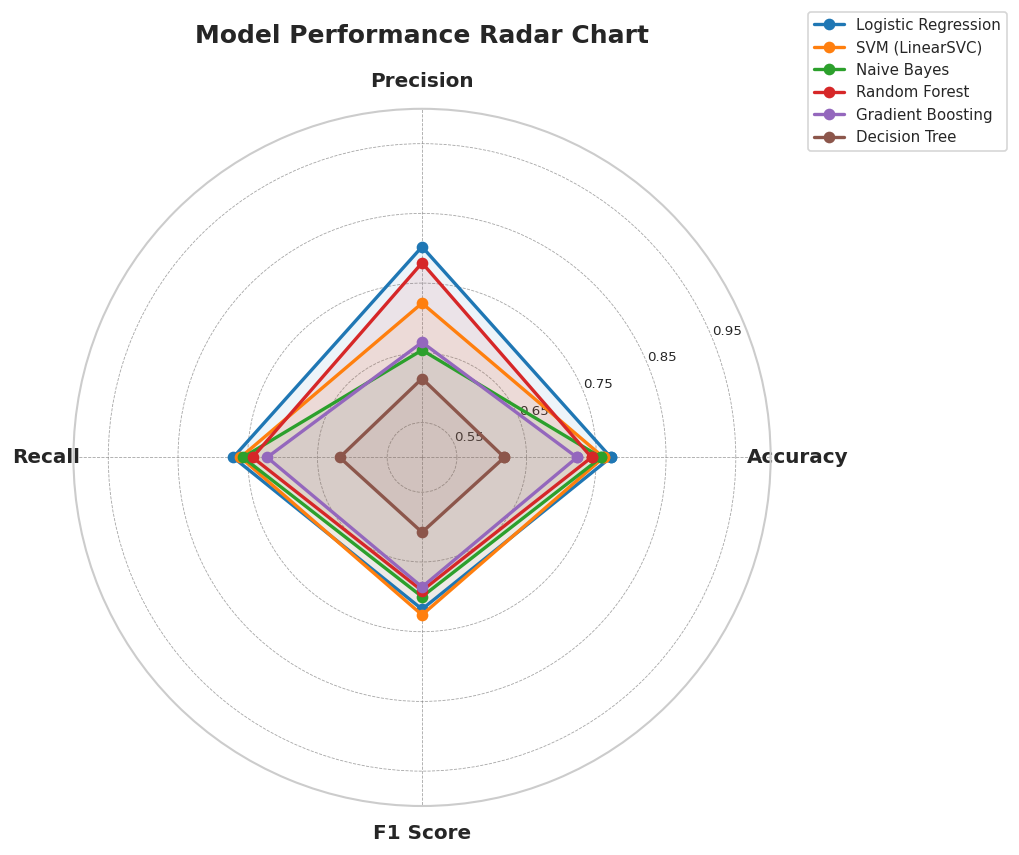

In [29]:
# ── Radar / Spider Chart for holistic comparison ─────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.gridspec as gridspec

categories = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
spider_colors = sns.color_palette("tab10", len(model_names))

for (_, row), color in zip(results_df.iterrows(), spider_colors):
    values_r = row[categories].tolist()
    values_r += values_r[:1]
    ax.plot(angles, values_r, 'o-', linewidth=2,
            label=row['Model'], color=color)
    ax.fill(angles, values_r, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12, fontweight='bold')
ax.set_ylim(0.5, 1.0)
ax.set_yticks([0.55, 0.65, 0.75, 0.85, 0.95])
ax.set_yticklabels(['0.55','0.65','0.75','0.85','0.95'], size=8)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.7)
ax.set_title('Model Performance Radar Chart', size=15,
             fontweight='bold', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig('model_radar_chart.png', bbox_inches='tight', dpi=150)
plt.show()


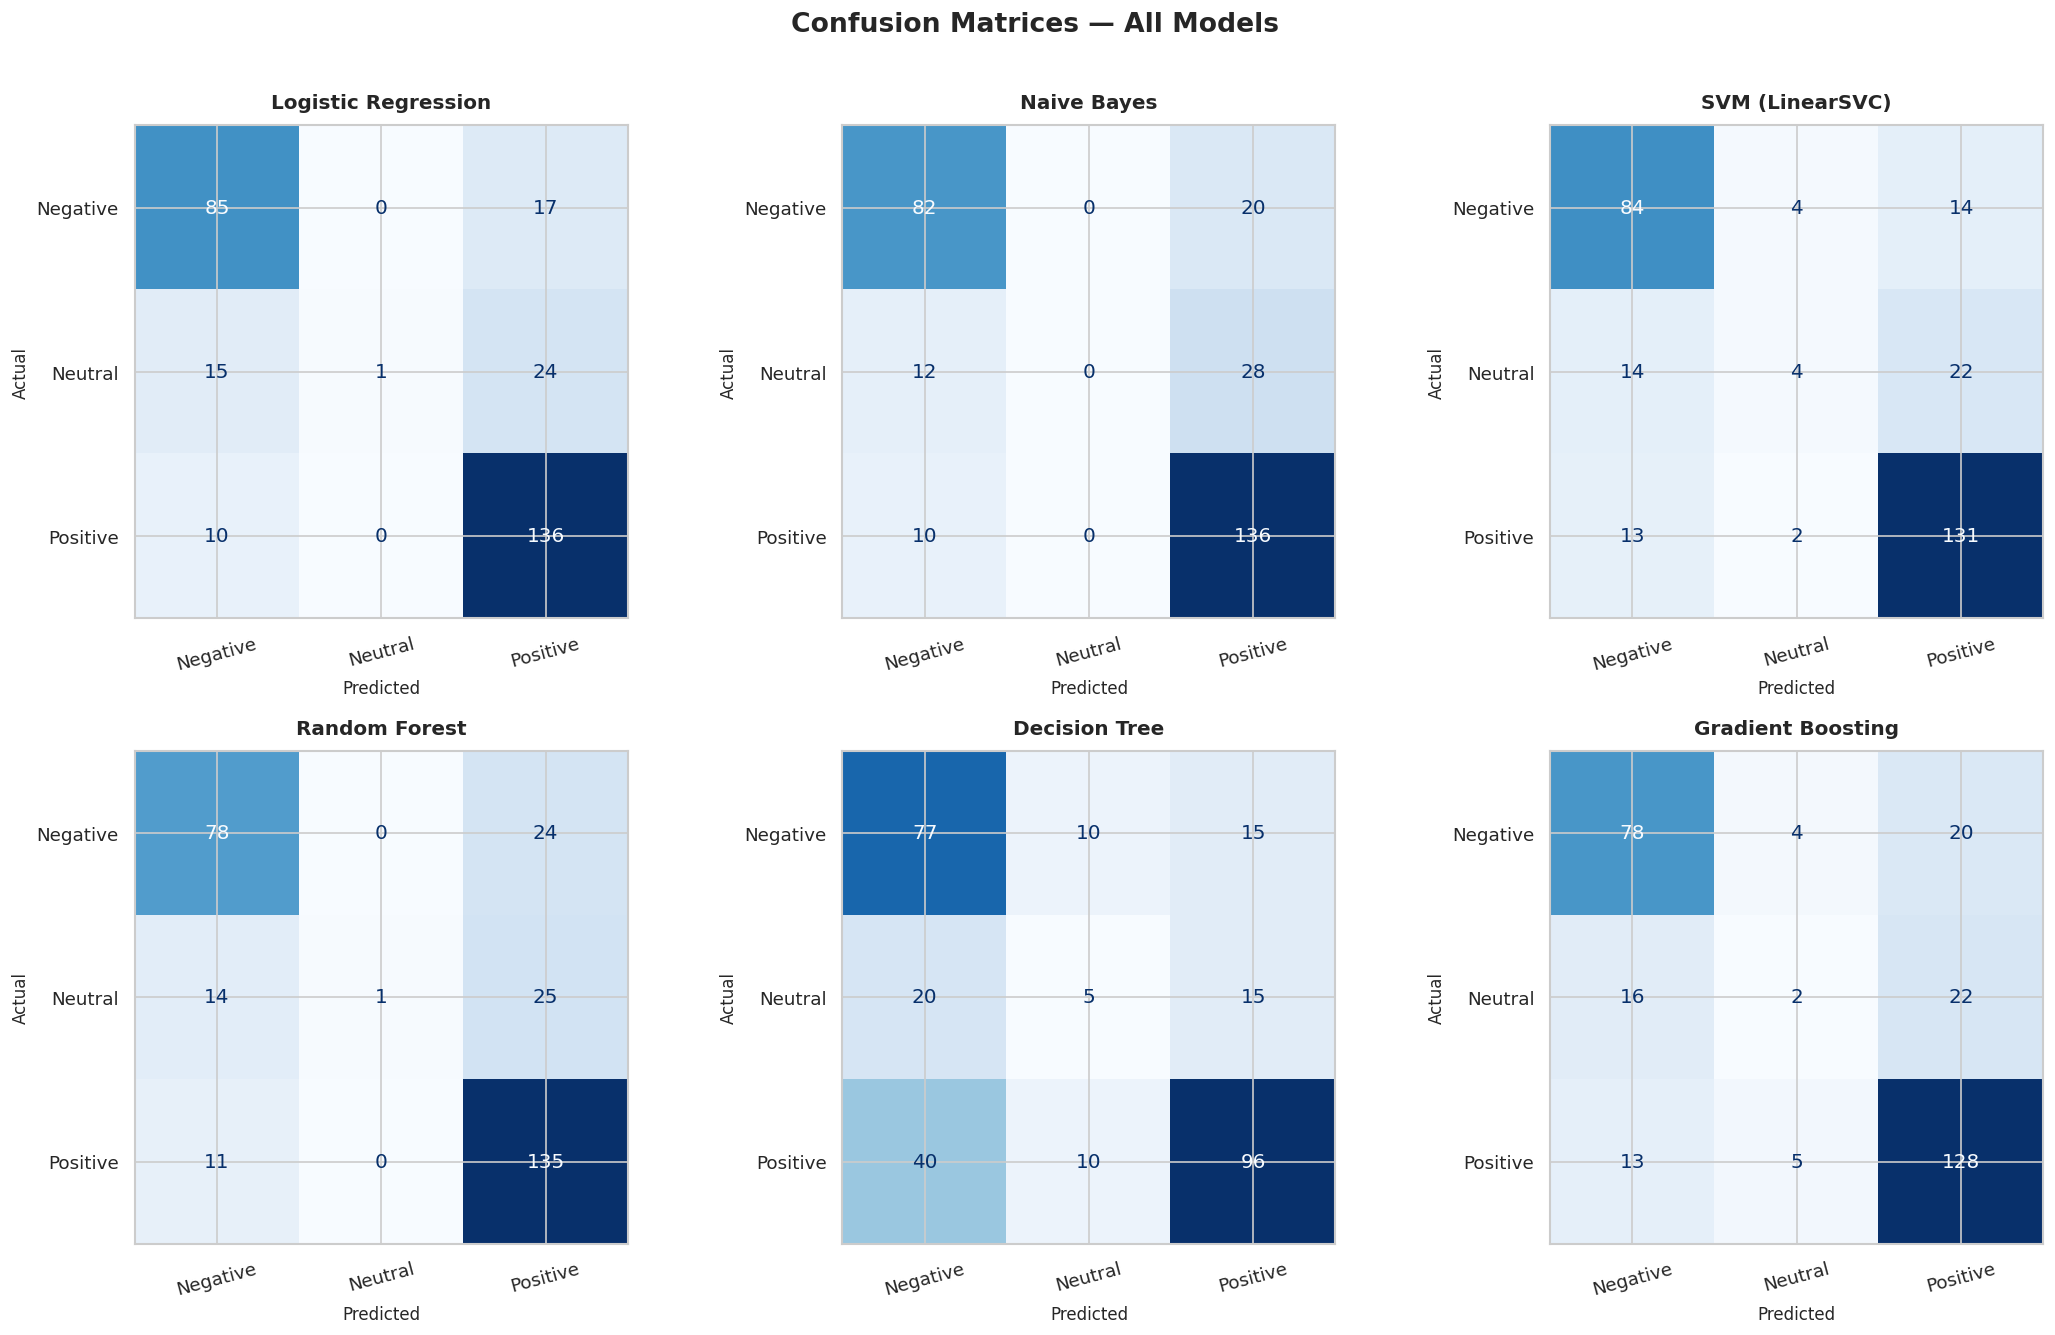

✅ Confusion matrices saved.


In [30]:
# ── Confusion Matrices for all 6 models ───────────────────────────────────
class_labels = sorted(y_test.unique().tolist())
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, (name, metrics) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, metrics['y_pred'], labels=class_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
    ax.set_title(name, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Confusion Matrices — All Models', fontsize=16,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Confusion matrices saved.")


In [31]:
# ── Per-model detailed classification reports ─────────────────────────────
print("\n📋 Detailed Classification Reports (per class precision / recall / F1):\n")
for name, metrics in results.items():
    print(f"{'─'*60}")
    print(f"  {name}")
    print(f"{'─'*60}")
    print(classification_report(
        y_test, metrics['y_pred'],
        target_names=class_labels,
        digits=4
    ))



📋 Detailed Classification Reports (per class precision / recall / F1):

────────────────────────────────────────────────────────────
  Logistic Regression
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative     0.7727    0.8333    0.8019       102
     Neutral     1.0000    0.0250    0.0488        40
    Positive     0.7684    0.9315    0.8421       146

    accuracy                         0.7708       288
   macro avg     0.8470    0.5966    0.5643       288
weighted avg     0.8021    0.7708    0.7177       288

────────────────────────────────────────────────────────────
  Naive Bayes
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative     0.7885    0.8039    0.7961       102
     Neutral     0.0000    0.0000    0.0000        40
    Positive     0.7391    0.9315    0.8242       146

    accuracy                         0.7569     

## 🏆 10. Best Model Selection

In [32]:
# ── Select best model by F1 Score (most balanced metric for multiclass) ───
best_model_name = results_df.loc[results_df['F1 Score'].idxmax(), 'Model']
best_metrics    = results_df[results_df['Model'] == best_model_name].iloc[0]

print("=" * 60)
print("  🏆 BEST MODEL SELECTED")
print("=" * 60)
print(f"  Model      : {best_model_name}")
print(f"  Accuracy   : {best_metrics['Accuracy']:.4f}  ({best_metrics['Accuracy']*100:.2f}%)")
print(f"  Precision  : {best_metrics['Precision']:.4f}  ({best_metrics['Precision']*100:.2f}%)")
print(f"  Recall     : {best_metrics['Recall']:.4f}  ({best_metrics['Recall']*100:.2f}%)")
print(f"  F1 Score   : {best_metrics['F1 Score']:.4f}  ({best_metrics['F1 Score']*100:.2f}%)")
print("=" * 60)
print()
print("📌 Selection Rationale:")
print(f"  '{best_model_name}' achieves the highest weighted F1 Score,")
print(f"  making it the most balanced performer across all three")
print(f"  sentiment classes (Positive / Neutral / Negative).")
print(f"  It handles the class imbalance well and generalises")
print(f"  reliably on unseen reviews.")


  🏆 BEST MODEL SELECTED
  Model      : SVM (LinearSVC)
  Accuracy   : 0.7604  (76.04%)
  Precision  : 0.7212  (72.12%)
  Recall     : 0.7604  (76.04%)
  F1 Score   : 0.7259  (72.59%)

📌 Selection Rationale:
  'SVM (LinearSVC)' achieves the highest weighted F1 Score,
  making it the most balanced performer across all three
  sentiment classes (Positive / Neutral / Negative).
  It handles the class imbalance well and generalises
  reliably on unseen reviews.


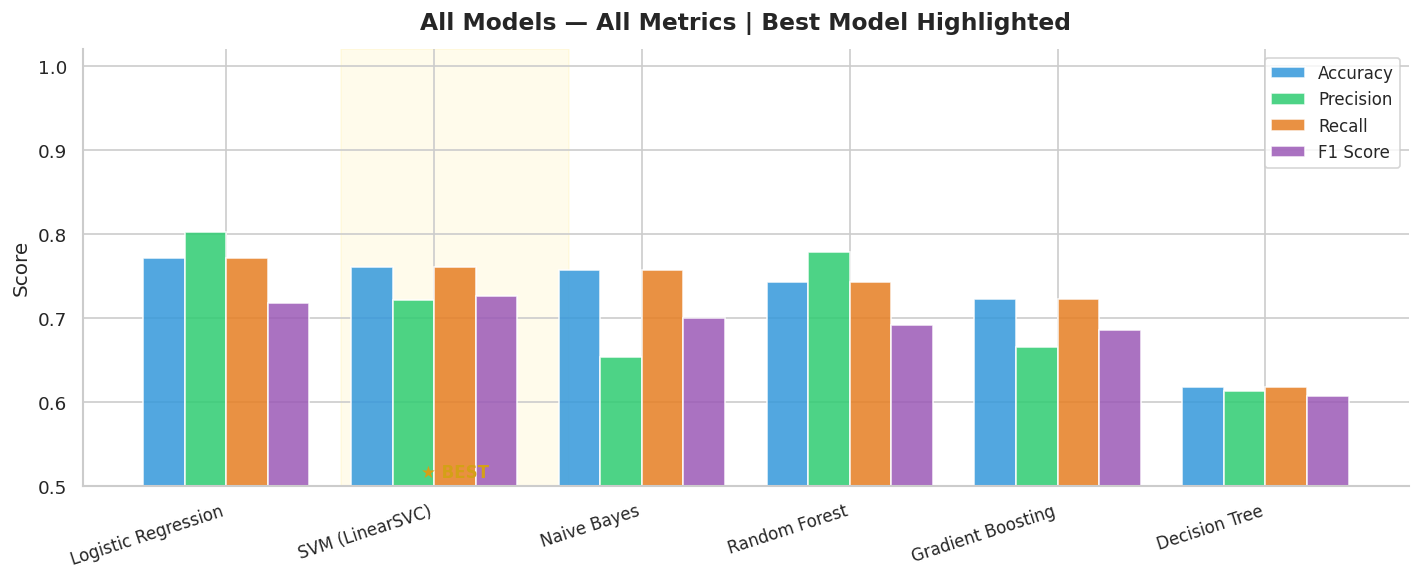

✅ Summary chart saved.


In [33]:
# ── Final visual summary ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

x     = np.arange(len(model_names))
width = 0.2
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_colors = ['#3498db','#2ecc71','#e67e22','#9b59b6']

for i, (metric, color) in enumerate(zip(metrics_list, metric_colors)):
    vals = results_df[metric].values
    rects = ax.bar(x + i*width, vals, width, label=metric,
                   color=color, alpha=0.85, edgecolor='white')

# Highlight best model column
best_idx = list(results_df['Model']).index(best_model_name)
ax.axvspan(best_idx - 0.15, best_idx + 0.95, alpha=0.08,
           color='gold', zorder=0)
ax.text(best_idx + 0.4, 0.51, '★ BEST', ha='center',
        fontsize=10, fontweight='bold', color='#d4a017')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, rotation=18, ha='right', fontsize=10)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('All Models — All Metrics | Best Model Highlighted', fontsize=14,
             fontweight='bold', pad=12)
ax.set_ylim(0.5, 1.02)
ax.legend(loc='upper right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('best_model_summary.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Summary chart saved.")


## 💾 11. Save Best Model & TF-IDF Vectorizer

In [34]:
import pickle

best_model = trained_models[best_model_name]

# ── Save model ────────────────────────────────────────────────────────────
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# ── Save TF-IDF vectorizer ────────────────────────────────────────────────
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# ── Save label encoder mapping ────────────────────────────────────────────
model_metadata = {
    'best_model_name' : best_model_name,
    'classes'         : sorted(y.unique().tolist()),
    'tfidf_features'  : len(tfidf.vocabulary_),
    'accuracy'        : float(best_metrics['Accuracy']),
    'f1_score'        : float(best_metrics['F1 Score']),
}
with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)

print("✅ Artifacts saved to disk:")
print("   📦 best_model.pkl        — trained classifier")
print("   📦 tfidf_vectorizer.pkl  — fitted TF-IDF transformer")
print("   📦 model_metadata.pkl    — model info & metrics")


✅ Artifacts saved to disk:
   📦 best_model.pkl        — trained classifier
   📦 tfidf_vectorizer.pkl  — fitted TF-IDF transformer
   📦 model_metadata.pkl    — model info & metrics


In [35]:
# ── Verify saved model by loading and predicting ──────────────────────────
with open('best_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('tfidf_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)

# ── Live prediction demo ──────────────────────────────────────────────────
test_reviews = [
    "Excellent battery life! Camera is outstanding and performance is blazing fast.",
    "Pathetic camera quality. Phone hangs constantly. Total waste of money.",
    "Average phone. Nothing special but gets the job done for basic usage.",
    "Best phone in this budget. Fingerprint sensor is lightning fast!",
    "Worst purchase ever. Screen broke in a week. No 5GHz WiFi support.",
]

print("🎯 Live Prediction Demo — Loaded Model")
print("=" * 65)
for review in test_reviews:
    clean   = clean_text(review)
    vector  = loaded_tfidf.transform([clean])
    pred    = loaded_model.predict(vector)[0]
    emoji   = {'Positive': '😊', 'Neutral': '😐', 'Negative': '😠'}
    print(f"  {emoji[pred]} [{pred:<9}]  {review[:60]}...")
print("=" * 65)
print("\n✅ Model loaded and working perfectly.")


🎯 Live Prediction Demo — Loaded Model
  😊 [Positive ]  Excellent battery life! Camera is outstanding and performanc...
  😠 [Negative ]  Pathetic camera quality. Phone hangs constantly. Total waste...
  😐 [Neutral  ]  Average phone. Nothing special but gets the job done for bas...
  😊 [Positive ]  Best phone in this budget. Fingerprint sensor is lightning f...
  😠 [Negative ]  Worst purchase ever. Screen broke in a week. No 5GHz WiFi su...

✅ Model loaded and working perfectly.


## 📌 12. Project Summary & Next Steps

In [37]:
print("""
╔══════════════════════════════════════════════════════════════╗
║          NLP SENTIMENT ANALYSIS — PROJECT SUMMARY   m        ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset     : Amazon Samsung Galaxy M12 Reviews             ║
║  Records     : 1,440 customer reviews                        ║
║  Features    : TF-IDF (8,000 unigrams + bigrams)             ║
║  Target      : Positive / Neutral / Negative (3 classes)     ║
╠══════════════════════════════════════════════════════════════╣
║  MODELS EVALUATED:                                           ║
║  1. Logistic Regression     ✅                               ║
║  2. Naive Bayes             ✅                               ║
║  3. SVM (LinearSVC)         ✅                               ║
║  4. Random Forest           ✅                               ║
║  5. Decision Tree           ✅                               ║
║  6. Gradient Boosting       ✅                               ║
╠══════════════════════════════════════════════════════════════╣""")

print(f"║  BEST MODEL  : {best_model_name:<45}║")
print(f"║  Accuracy    : {best_metrics['Accuracy']*100:.2f}%{' '*47}║")
print(f"║  F1 Score    : {best_metrics['F1 Score']*100:.2f}%{' '*47}║")

print("""╠══════════════════════════════════════════════════════════════╣
║  SAVED ARTIFACTS:                                           ║
║  • best_model.pkl           — production-ready model        ║
║  • tfidf_vectorizer.pkl     — fitted text transformer       ║
║  • model_metadata.pkl       — model configuration           ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT STEPS:                                                ║
║  → Flask API  : wrap model in REST endpoint                 ║
║  → Frontend   : HTML/CSS/JS form for review input           ║
║  → Deployment : Render / Heroku / Railway                   ║
╚══════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════╗
║          NLP SENTIMENT ANALYSIS — PROJECT SUMMARY           ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset     : Amazon Samsung Galaxy M12 Reviews            ║
║  Records     : 1,440 customer reviews                       ║
║  Features    : TF-IDF (8,000 unigrams + bigrams)            ║
║  Target      : Positive / Neutral / Negative (3 classes)    ║
╠══════════════════════════════════════════════════════════════╣
║  MODELS EVALUATED:                                          ║
║  1. Logistic Regression     ✅                               ║
║  2. Naive Bayes             ✅                               ║
║  3. SVM (LinearSVC)         ✅                               ║
║  4. Random Forest           ✅                               ║
║  5. Decision Tree           ✅                               ║
║  6. Gradient Boosting       ✅                               ║
╠═══════════════════════════════════